In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
from sklearn.model_selection import train_test_split
from scipy import stats

In [10]:
# Use the name of the uploaded file
if 'uploaded_file_name' in locals() and uploaded_file_name is not None:
  path = f"/content/{uploaded_file_name}"
  df = pd.read_csv(path)
  print(f"Successfully loaded '{uploaded_file_name}' into DataFrame.")
else:
  print("Please upload the CSV file using the previous cell first.")

Successfully loaded 'samplesuperstore - samplesuperstore.csv' into DataFrame.


In [9]:
from google.colab import files
uploaded = files.upload()

# Get the name of the first uploaded file
if uploaded:
  uploaded_file_name = list(uploaded.keys())[0]
  print(f'User uploaded file "{uploaded_file_name}" with length {len(uploaded[uploaded_file_name])} bytes')
else:
  uploaded_file_name = None
  print("No file was uploaded.")

Saving samplesuperstore - samplesuperstore.csv to samplesuperstore - samplesuperstore.csv
User uploaded file "samplesuperstore - samplesuperstore.csv" with length 2332594 bytes


In [11]:
print(df.head())

   Row ID        Order ID Order Date  Ship Date       Ship Mode Customer ID  \
0       1  US-2023-103800   1/3/2023   1/7/2023  Standard Class    DP-13000   
1       2  US-2023-112326   1/4/2023   1/8/2023  Standard Class    PO-19195   
2       3  US-2023-112326   1/4/2023   1/8/2023  Standard Class    PO-19195   
3       4  US-2023-112326   1/4/2023   1/8/2023  Standard Class    PO-19195   
4       5  US-2023-141817   1/5/2023  1/12/2023  Standard Class    MB-18085   

   Customer Name      Segment Country/Region          City  ... Postal Code  \
0  Darren Powers     Consumer  United States       Houston  ...       77095   
1  Phillina Ober  Home Office  United States    Naperville  ...       60540   
2  Phillina Ober  Home Office  United States    Naperville  ...       60540   
3  Phillina Ober  Home Office  United States    Naperville  ...       60540   
4     Mick Brown     Consumer  United States  Philadelphia  ...       19143   

    Region       Product ID         Category Sub-C

In [12]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  object 
 2   Order Date      10194 non-null  object 
 3   Ship Date       10194 non-null  object 
 4   Ship Mode       10194 non-null  object 
 5   Customer ID     10194 non-null  object 
 6   Customer Name   10194 non-null  object 
 7   Segment         10194 non-null  object 
 8   Country/Region  10194 non-null  object 
 9   City            10194 non-null  object 
 10  State/Province  10194 non-null  object 
 11  Postal Code     10194 non-null  object 
 12  Region          10194 non-null  object 
 13  Product ID      10194 non-null  object 
 14  Category        10194 non-null  object 
 15  Sub-Category    10194 non-null  object 
 16  Product Name    10194 non-null  object 
 17  Sales           10194 non-null 

In [13]:
print(df.describe())

             Row ID         Sales      Quantity      Discount        Profit
count  10194.000000  10194.000000  10194.000000  10194.000000  10194.000000
mean    5097.500000    228.225854      3.791838      0.155385     28.673417
std     2942.898656    619.906839      2.228317      0.206249    232.465115
min        1.000000      0.444000      1.000000      0.000000  -6599.978000
25%     2549.250000     17.220000      2.000000      0.000000      1.760800
50%     5097.500000     53.910000      3.000000      0.200000      8.690000
75%     7645.750000    209.500000      5.000000      0.200000     29.297925
max    10194.000000  22638.480000     14.000000      0.800000   8399.976000


In [14]:
print(df.isnull().sum())

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country/Region    0
City              0
State/Province    0
Postal Code       0
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Quantity          0
Discount          0
Profit            0
dtype: int64


In [15]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

df["Category"] = df["Category"].str.strip().str.title()
df["Sub-Category"] = df["Sub-Category"].str.strip().str.title()
df["Segment"] = df["Segment"].str.strip().str.title()

In [16]:
print(df[["Sales", "Profit", "Quantity", "Discount"]].describe())

print("Average Sales:", np.mean(df["Sales"]))

sales = df.groupby("Category")["Sales"].sum()
print(sales)

              Sales        Profit      Quantity      Discount
count  10194.000000  10194.000000  10194.000000  10194.000000
mean     228.225854     28.673417      3.791838      0.155385
std      619.906839    232.465115      2.228317      0.206249
min        0.444000  -6599.978000      1.000000      0.000000
25%       17.220000      1.760800      2.000000      0.000000
50%       53.910000      8.690000      3.000000      0.200000
75%      209.500000     29.297925      5.000000      0.200000
max    22638.480000   8399.976000     14.000000      0.800000
Average Sales: 228.22585386501862
Category
Furniture          754747.7613
Office Supplies    731893.3140
Technology         839893.2790
Name: Sales, dtype: float64


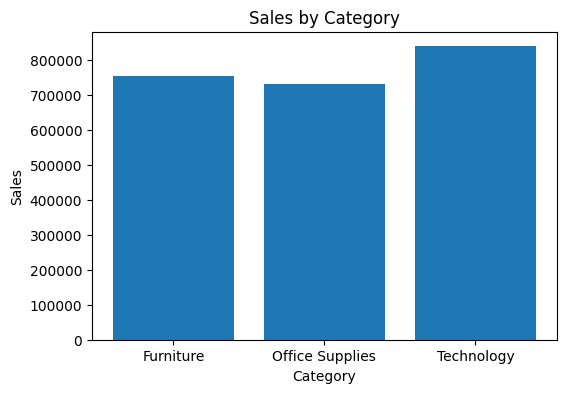

In [17]:
plt.figure(figsize=(6,4))
plt.bar(sales.index, sales.values)
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.show()



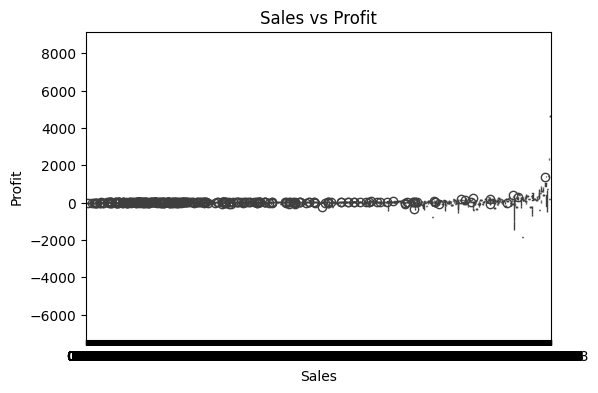

In [24]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="Sales", y="Profit")
plt.title("Sales vs Profit")
plt.show()

In [19]:
X_train, X_test = train_test_split(df, test_size=0.2, random_state=42)


In [20]:
print("Training Rows:", len(X_train))
print("Testing Rows:", len(X_test))


Training Rows: 8155
Testing Rows: 2039


In [21]:
print("Mean Sales:", stats.tmean(df["Sales"]))

Mean Sales: 228.22585386501862
